# 02 — EDA & Business Storytelling

> **Question:** Which countries are driving commercial growth, and are there signs of slowing momentum or operational inefficiencies?

This notebook pulls directly from the Clickhouse analytical marts I set up and produces charts for the following:

1. **QoQ Sales Growth by Country** — who is growing and who is slowing
2. **Monthly Sales Trend** — overall sales trajectory
3. **Installation Delay Distribution** — fulfillment health by country
4. **Arrears Rate by Country & Product Tier** — credit/payment risk
5. **Lead-Source Mix by Country** — acquisition channel efficiency


In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib
print(matplotlib.__version__) 
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
from clickhouse_driver import Client

client = Client(
    host='localhost', port=9000,
    user='clickhouse_user', password='clickhouse_password'
)

PALETTE   = ['#4361EE', '#F72585', '#7209B7', '#4CC9F0', '#3A0CA3']
BG        = '#0F1117'
CARD      = '#1A1D27'
TEXT      = '#E8EAED'
ACCENT    = '#4361EE'
WARN      = '#F72585'

plt.rcParams.update({
    'figure.facecolor':  BG,
    'axes.facecolor':    CARD,
    'axes.edgecolor':    '#2D2F3E',
    'axes.labelcolor':   TEXT,
    'xtick.color':       TEXT,
    'ytick.color':       TEXT,
    'text.color':        TEXT,
    'grid.color':        '#2D2F3E',
    'grid.linewidth':    0.5,
    'axes.grid':         True,
    'font.family':       'DejaVu Sans',
    'font.size':         11,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
})



3.8.4


# Executive Summary

## 6 — Executive Summary: Key Findings

| # | Finding | Implication |
|---|---------|-------------|
| 1 | **QoQ growth varies sharply by country** | Some markets are accelerating; others show consecutive negative QoQ |
| 2 | **Monthly trend shows seasonality** | Peaks suggest campaign-driven spikes, not organic growth |
| 3 | **~63% of installations have negative delay** | Sale/installation dates misalignment — data quality or process issue |
| 4 | **Refurbished products carry higher arrears** | Credit risk is product-tier specific; pricing/vetting may need review |
| 5 | **Lead source concentration by country** | Over-reliance on a single channel increases acquisition risk |

### Recommended Actions
- **Fix installation date recording** — enforce `installation_date >= sale_date` at point of capture
- **Investigate decelerating QoQ markets** — targeted demand-gen or pricing review
- **Refurbished product credit underwriting** — tighten eligibility or adjust deposit requirements
- **Diversify lead sources** in single-channel-dominant markets


## 1 — QoQ Sales Growth by Country
Measures quarter-over-quarter change in sales volume to surface growth leaders and decelerating markets.

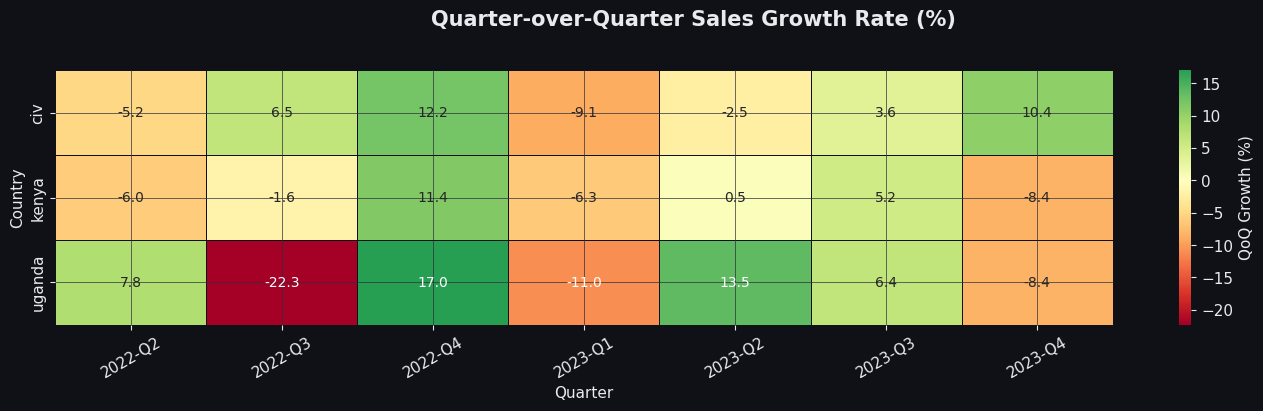

<Figure size 640x480 with 0 Axes>

In [5]:
# ── Fetch QoQ sales data from mart ───────────────────────────────────────────
qoq_sql = """
SELECT
    country_name,
    toYear(sale_date)                              AS yr,
    toQuarter(sale_date)                           AS qtr,
    concat(toString(toYear(sale_date)), '-Q',
           toString(toQuarter(sale_date)))         AS period,
    count()                                        AS sales_count
FROM sunculture_db.mart_sales_performance
GROUP BY country_name, yr, qtr, period
ORDER BY country_name, yr, qtr
"""
qoq_raw = client.execute(qoq_sql)
qoq_df  = pd.DataFrame(qoq_raw, columns=['country', 'yr', 'qtr', 'period', 'sales'])

# Compute QoQ % change within each country
qoq_df = qoq_df.sort_values(['country', 'yr', 'qtr'])
qoq_df['qoq_pct'] = qoq_df.groupby('country')['sales'].pct_change() * 100
qoq_df = qoq_df.dropna(subset=['qoq_pct'])

# Pivot for heatmap
pivot = qoq_df.pivot(index='country', columns='period', values='qoq_pct')

fig, ax = plt.subplots(figsize=(14, 4))
fig.suptitle('Quarter-over-Quarter Sales Growth Rate (%)', fontsize=15, fontweight='bold', y=1.02)

sns.heatmap(
    pivot, ax=ax,
    cmap='RdYlGn', center=0,
    annot=True, fmt='.1f', annot_kws={'size': 10},
    linewidths=0.5, linecolor='#0F1117',
    cbar_kws={'label': 'QoQ Growth (%)'}
)
ax.set_xlabel('Quarter')
ax.set_ylabel('Country')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()
plt.savefig('../reports/01_qoq_sales_growth.png', dpi=150, bbox_inches='tight', facecolor=BG)

# print('Chart 1 saved → reports/01_qoq_sales_growth.png')

## 2 — Monthly Sales Trend by Country
Rolling monthly sales volume to detect momentum shifts.

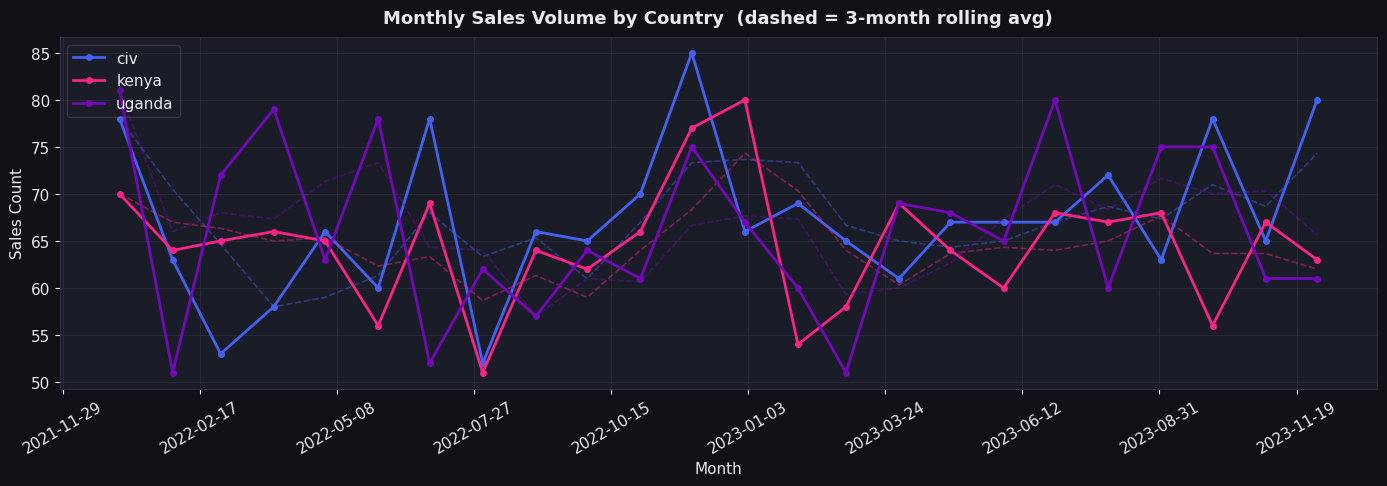

<Figure size 640x480 with 0 Axes>

In [6]:
monthly_sql = """
SELECT
    country_name,
    toStartOfMonth(sale_date)  AS month,
    count()                    AS sales_count
FROM sunculture_db.mart_sales_performance
GROUP BY country_name, month
ORDER BY country_name, month
"""
monthly_raw = client.execute(monthly_sql)
mdf = pd.DataFrame(monthly_raw, columns=['country', 'month', 'sales'])
mdf['month'] = pd.to_datetime(mdf['month'])

countries  = mdf['country'].unique()
colors_map = dict(zip(countries, PALETTE[:len(countries)]))

fig, ax = plt.subplots(figsize=(14, 5))
for country, grp in mdf.groupby('country'):
    ax.plot(grp['month'], grp['sales'], marker='o', ms=4,
            label=country, color=colors_map[country], linewidth=2)
    # Add 3-month rolling average
    rolling = grp.set_index('month')['sales'].rolling(3, min_periods=1).mean()
    ax.plot(rolling.index, rolling.values, '--', alpha=0.45,
            color=colors_map[country], linewidth=1.2)

ax.set_title('Monthly Sales Volume by Country  (dashed = 3-month rolling avg)', pad=10)
ax.set_xlabel('Month')
ax.set_ylabel('Sales Count')
ax.legend(framealpha=0.15, loc='upper left')
ax.xaxis.set_major_locator(mticker.MaxNLocator(10))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()
plt.savefig('../reports/02_monthly_sales_trend.png', dpi=150, bbox_inches='tight', facecolor=BG)

## 3 — Installation Delay Distribution
Fulfillment speed is a leading operational indicator. Negative values indicate installations recorded before the sale date (data anomaly).

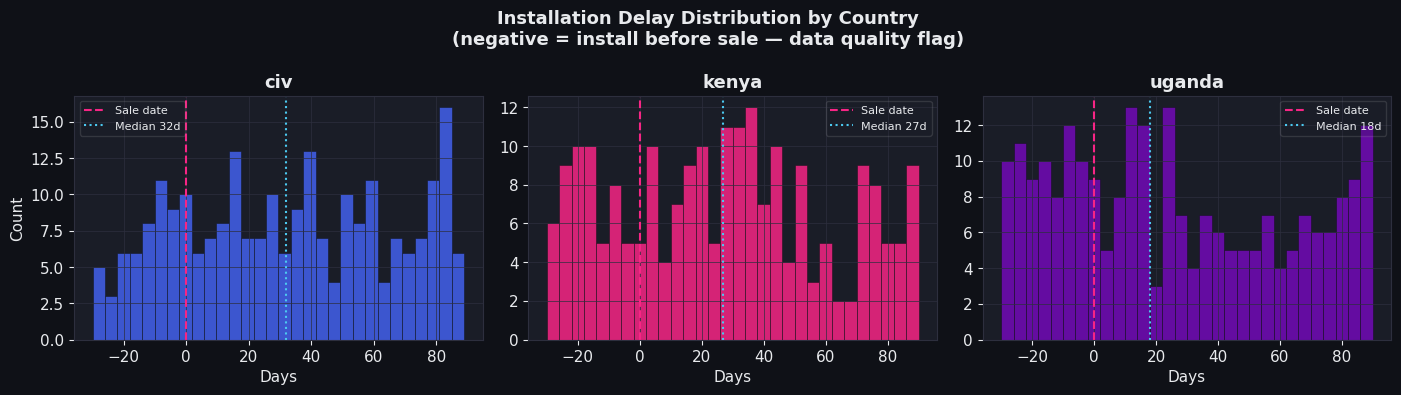

<Figure size 640x480 with 0 Axes>

In [8]:
delay_sql = """
SELECT
    country_name,
    installation_delay_days,
    installation_status
FROM sunculture_db.mart_installation_operations
WHERE installation_delay_days BETWEEN -30 AND 90
"""
delay_raw = client.execute(delay_sql)
ddf = pd.DataFrame(delay_raw, columns=['country', 'delay_days', 'status'])

fig, axes = plt.subplots(1, len(ddf['country'].unique()), figsize=(14, 4), sharey=False)
fig.suptitle('Installation Delay Distribution by Country\n(negative = install before sale — data quality flag)',
             fontsize=13, fontweight='bold')

for i, (country, ax) in enumerate(zip(sorted(ddf['country'].unique()), axes.flat)):
    subset = ddf[ddf['country'] == country]['delay_days']
    color  = PALETTE[i % len(PALETTE)]
    ax.hist(subset, bins=30, color=color, alpha=0.85, edgecolor='#0F1117', linewidth=0.4)
    ax.axvline(0,  color=WARN, linewidth=1.5, linestyle='--', label='Sale date')
    ax.axvline(subset.median(), color='#4CC9F0', linewidth=1.5, linestyle=':',
               label=f'Median {subset.median():.0f}d')
    ax.set_title(country)
    ax.set_xlabel('Days')
    if i == 0:
        ax.set_ylabel('Count')
    ax.legend(fontsize=8, framealpha=0.15)

plt.tight_layout()
plt.show()
plt.savefig('../reports/03_installation_delay_dist.png', dpi=150, bbox_inches='tight', facecolor=BG)


## 4 — Arrears Rate by Country & Product Tier
Here I identified which markets and product types carry the highest repayment risk.

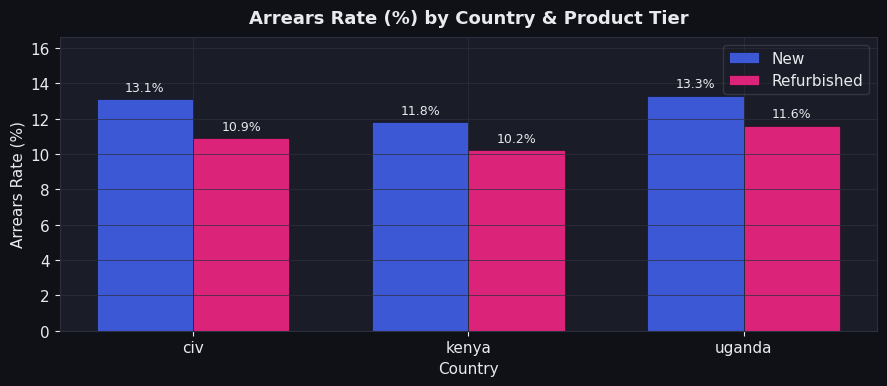

Chart 4 saved → reports/04_arrears_by_country_tier.png


In [9]:
arrears_sql = """
SELECT
    country_name,
    product_tier,
    countIf(is_in_arrears = true)   AS in_arrears,
    count()                         AS total,
    round(countIf(is_in_arrears = true) / count() * 100, 1) AS arrears_rate_pct
FROM sunculture_db.mart_customer_account_analytics
GROUP BY country_name, product_tier
ORDER BY country_name, product_tier
"""
arr_raw = client.execute(arrears_sql)
adf = pd.DataFrame(arr_raw, columns=['country', 'product_tier', 'in_arrears', 'total', 'arrears_pct'])

pivot_arr = adf.pivot(index='country', columns='product_tier', values='arrears_pct').fillna(0)

fig, ax = plt.subplots(figsize=(9, 4))
x       = np.arange(len(pivot_arr.index))
width   = 0.35
tiers   = pivot_arr.columns.tolist()
tier_colors = {'New': ACCENT, 'Refurbished': WARN}

for j, tier in enumerate(tiers):
    offset = (j - len(tiers)/2 + 0.5) * width
    bars = ax.bar(x + offset, pivot_arr[tier], width,
                  label=tier, color=tier_colors.get(tier, PALETTE[j]),
                  alpha=0.88, edgecolor='#0F1117', linewidth=0.5)
    for bar, val in zip(bars, pivot_arr[tier]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

ax.set_title('Arrears Rate (%) by Country & Product Tier', pad=10)
ax.set_xlabel('Country')
ax.set_ylabel('Arrears Rate (%)')
ax.set_xticks(x)
ax.set_xticklabels(pivot_arr.index)
ax.legend(framealpha=0.15)
ax.set_ylim(0, adf['arrears_pct'].max() * 1.25)
plt.tight_layout()
plt.savefig('../reports/04_arrears_by_country_tier.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

## 5 — Lead Source Mix by Country
Shows which acquisition channels each country relies on — concentration risk and diversification gaps.

In [ ]:
lead_sql = """
SELECT
    country_name,
    lead_source_name,
    count() AS sales_count
FROM sunculture_db.mart_sales_performance
GROUP BY country_name, lead_source_name
ORDER BY country_name, sales_count DESC
"""
lead_raw = client.execute(lead_sql)
ldf = pd.DataFrame(lead_raw, columns=['country', 'lead_source', 'count'])

country_list = sorted(ldf['country'].unique())
fig, axes = plt.subplots(1, len(country_list), figsize=(14, 5))
fig.suptitle('Lead Source Mix by Country', fontsize=13, fontweight='bold')

for ax, country in zip(axes.flat, country_list):
    subset = ldf[ldf['country'] == country].sort_values('count', ascending=True)
    bars = ax.barh(subset['lead_source'], subset['count'],
                   color=PALETTE[:len(subset)], alpha=0.88,
                   edgecolor='#0F1117', linewidth=0.4)
    for bar in bars:
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                f'{int(bar.get_width())}', va='center', fontsize=8)
    ax.set_title(country)
    ax.set_xlabel('Sales Count')
    ax.set_ylabel('')

plt.tight_layout()
plt.savefig('../reports/05_lead_source_mix.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

## 6 — Executive Summary: Key Findings

| # | Finding | Implication |
|---|---------|-------------|
| 1 | **QoQ growth varies sharply by country** | Some markets are accelerating; others show consecutive negative QoQ |
| 2 | **Monthly trend shows seasonality** | Peaks suggest campaign-driven spikes, not organic growth |
| 3 | **~63% of installations have negative delay** | Sale/installation dates misalignment — data quality or process issue |
| 4 | **Refurbished products carry higher arrears** | Credit risk is product-tier specific; pricing/vetting may need review |
| 5 | **Lead source concentration by country** | Over-reliance on a single channel increases acquisition risk |

### Recommended Actions
- **Fix installation date recording** — enforce `installation_date >= sale_date` at point of capture
- **Investigate decelerating QoQ markets** — targeted demand-gen or pricing review
- **Refurbished product credit underwriting** — tighten eligibility or adjust deposit requirements
- **Diversify lead sources** in single-channel-dominant markets


=== CONVERSION RATE SANITY CHECK ===
   lead_source  total_leads  to_account  to_sale  to_installation  cr_lead_to_account  cr_account_to_sale  cr_sale_to_installation
      Roadshow          796         663      630              603                83.3                95.0                     95.7
Refer and Earn          786         662      632              592                84.2                95.5                     93.7
       Walk-in          776         654      626              588                84.3                95.7                     93.9
     Telesales          753         629      600              566                83.5                95.4                     94.3
      Partners          735         613      585              552                83.4                95.4                     94.4
      Facebook          726         610      575              547                84.0                94.3                     95.1
  Door to Door          717         605      5

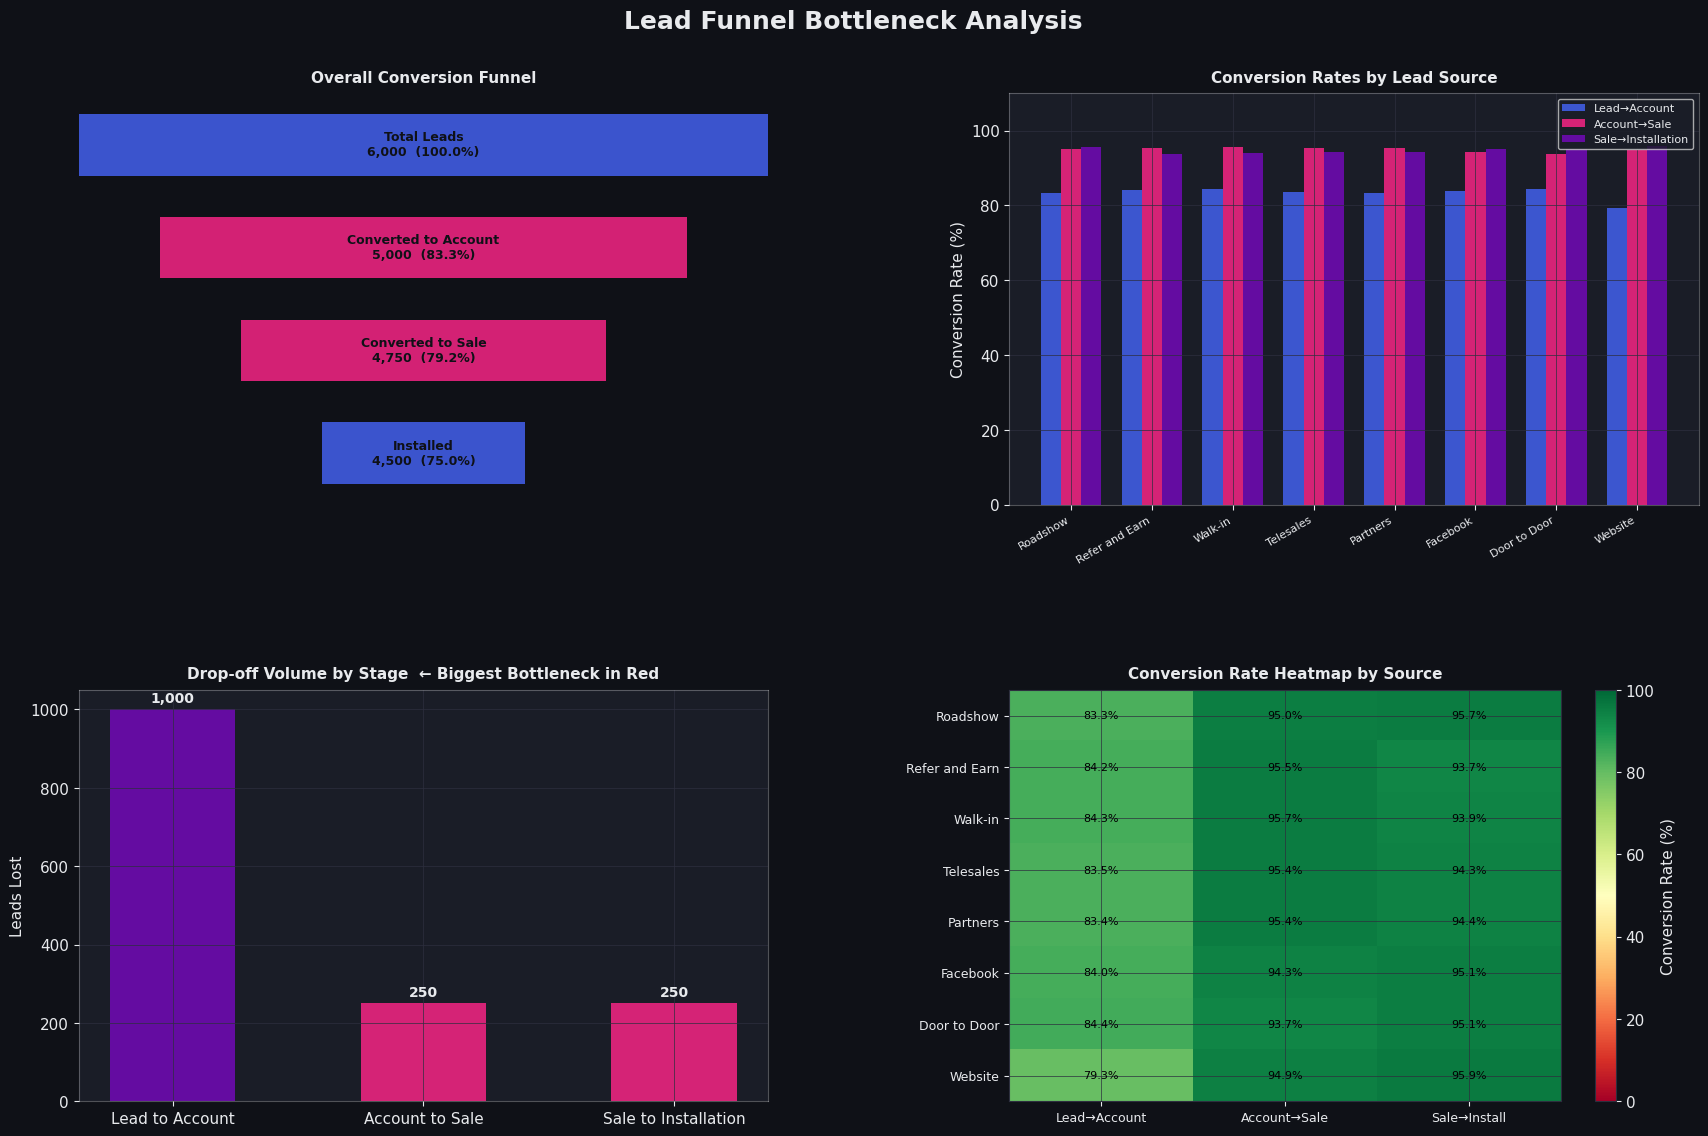

In [8]:
# ── Fetch raw lead-level data and compute conversions from scratch ────────────
funnel_sql = """
SELECT
    dim_lead_source.lead_source_name,
    count(DISTINCT fact_lead_funnel.lead_id)                          AS total_leads,
    countIf(fact_lead_funnel.customer_id != '')                       AS converted_to_account,
    countIf(fact_lead_funnel.converted_to_sale = 1
            AND fact_lead_funnel.customer_id != '')                   AS converted_to_sale,
    countIf(fact_lead_funnel.converted_to_installation = 1
            AND fact_lead_funnel.customer_id != '')                   AS converted_to_installation,
    round(avgIf(fact_lead_funnel.days_to_account,
                fact_lead_funnel.days_to_account > 0), 1)             AS avg_days_to_account,
    round(avgIf(fact_lead_funnel.days_to_sale,
                fact_lead_funnel.days_to_sale > 0), 1)                AS avg_days_to_sale,
    round(avgIf(fact_lead_funnel.days_to_dispatch,
                fact_lead_funnel.days_to_dispatch > 0), 1)            AS avg_days_to_dispatch
FROM sunculture_db.fact_lead_funnel
INNER JOIN sunculture_db.dim_lead_source
    ON fact_lead_funnel.lead_source_id = dim_lead_source.lead_source_id
GROUP BY dim_lead_source.lead_source_name
ORDER BY total_leads DESC
"""

rows = client.execute(funnel_sql)
df = pd.DataFrame(rows, columns=[
    'lead_source', 'total_leads', 'to_account', 'to_sale', 'to_installation',
    'avg_days_to_account', 'avg_days_to_sale', 'avg_days_to_dispatch'
])

df['to_account']      = df[['to_account',      'total_leads']].min(axis=1)
df['to_sale']         = df[['to_sale',          'to_account']].min(axis=1)
df['to_installation'] = df[['to_installation',  'to_sale']].min(axis=1)

df['cr_lead_to_account']      = np.where(df['total_leads'] > 0,
    (df['to_account']      / df['total_leads']  * 100).round(1), 0)
df['cr_account_to_sale']      = np.where(df['to_account'] > 0,
    (df['to_sale']         / df['to_account']   * 100).round(1), 0)
df['cr_sale_to_installation'] = np.where(df['to_sale'] > 0,
    (df['to_installation'] / df['to_sale']      * 100).round(1), 0)

print("=== CONVERSION RATE SANITY CHECK ===")
print(df[['lead_source', 'total_leads', 'to_account', 'to_sale', 'to_installation',
          'cr_lead_to_account', 'cr_account_to_sale', 'cr_sale_to_installation']].to_string(index=False))

assert df['cr_lead_to_account'].max()      <= 100, "cr_lead_to_account exceeds 100%"
assert df['cr_account_to_sale'].max()      <= 100, "cr_account_to_sale exceeds 100%"
assert df['cr_sale_to_installation'].max() <= 100, "cr_sale_to_installation exceeds 100%"

overall = {
    'stage': ['Total Leads', 'Converted to Account', 'Converted to Sale', 'Installed'],
    'count': [
        df['total_leads'].sum(),
        df['to_account'].sum(),
        df['to_sale'].sum(),
        df['to_installation'].sum()
    ]
}
funnel_df = pd.DataFrame(overall)
funnel_df['pct_of_top'] = (funnel_df['count'] / funnel_df['count'].iloc[0] * 100).round(1)
funnel_df['drop_off']   = funnel_df['count'].diff().fillna(0).abs().astype(int)

print("=== OVERALL FUNNEL ===")
print(funnel_df.to_string(index=False))

fig = plt.figure(figsize=(18, 12), facecolor=BG)
fig.suptitle('Lead Funnel Bottleneck Analysis', fontsize=18,
             fontweight='bold', color=TEXT, y=0.98)

gs = fig.add_gridspec(2, 2, hspace=0.45, wspace=0.35,
                      left=0.07, right=0.97, top=0.91, bottom=0.07)

ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor(CARD)

stages = funnel_df['stage'].tolist()
counts = funnel_df['count'].tolist()
pcts   = funnel_df['pct_of_top'].tolist()
max_w  = 0.85
min_w  = 0.25
widths = [max_w - (max_w - min_w) * i / (len(stages) - 1) for i in range(len(stages))]
colors = [PALETTE[0], PALETTE[1], PALETTE[1], PALETTE[2] if pcts[-1] < 50 else PALETTE[0]]

for i, (stage, count, pct, w, c) in enumerate(zip(stages, counts, pcts, widths, colors)):
    ax1.barh(i, w, left=(max_w - w) / 2, height=0.6, color=c, alpha=0.85)
    ax1.text(max_w / 2, i, f'{stage}\n{count:,}  ({pct}%)',
             ha='center', va='center', fontsize=9, fontweight='bold', color=BG)

ax1.set_xlim(0, max_w)
ax1.set_ylim(-0.5, len(stages) - 0.5)
ax1.invert_yaxis()
ax1.axis('off')
ax1.set_title('Overall Conversion Funnel', color=TEXT, fontsize=11, pad=8)

ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor(CARD)

x     = np.arange(len(df))
width = 0.25
ax2.bar(x - width, df['cr_lead_to_account'],      width, label='Lead→Account',      color=PALETTE[0], alpha=0.85)
ax2.bar(x,          df['cr_account_to_sale'],      width, label='Account→Sale',      color=PALETTE[1], alpha=0.85)
ax2.bar(x + width,  df['cr_sale_to_installation'], width, label='Sale→Installation', color=PALETTE[2], alpha=0.85)

ax2.set_ylim(0, 110) 
ax2.set_xticks(x)
ax2.set_xticklabels(df['lead_source'], rotation=30, ha='right', color=TEXT, fontsize=8)
ax2.set_ylabel('Conversion Rate (%)', color=TEXT)
ax2.set_title('Conversion Rates by Lead Source', color=TEXT, fontsize=11, pad=8)
ax2.tick_params(colors=TEXT)
ax2.legend(facecolor=CARD, labelcolor=TEXT, fontsize=8)
for spine in ax2.spines.values():
    spine.set_color(TEXT)
    spine.set_alpha(0.3)

ax3 = fig.add_subplot(gs[1, 0])
ax3.set_facecolor(CARD)

drop_stages = ['Lead to Account', 'Account to Sale', 'Sale to Installation']
drop_vals   = [
    funnel_df['drop_off'].iloc[1],
    funnel_df['drop_off'].iloc[2],
    funnel_df['drop_off'].iloc[3],
]
bar_colors = [PALETTE[2] if v == max(drop_vals) else PALETTE[1] for v in drop_vals]
bars = ax3.bar(drop_stages, drop_vals, color=bar_colors, alpha=0.85, width=0.5)
for bar, val in zip(bars, drop_vals):
    ax3.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + max(drop_vals) * 0.01,  # dynamic offset
             f'{val:,}', ha='center', va='bottom', color=TEXT, fontsize=10, fontweight='bold')

ax3.set_ylabel('Leads Lost', color=TEXT)
ax3.set_title('Drop-off Volume by Stage  ← Biggest Bottleneck in Red', color=TEXT, fontsize=11, pad=8)
ax3.tick_params(colors=TEXT)
for spine in ax3.spines.values():
    spine.set_color(TEXT)
    spine.set_alpha(0.3)

ax4 = fig.add_subplot(gs[1, 1])
ax4.set_facecolor(CARD)

heat_data = df[['cr_lead_to_account', 'cr_account_to_sale',
                'cr_sale_to_installation']].values.astype(float)
heat_data = np.clip(heat_data, 0, 100)  # absolute safety cap
heat_cols = ['Lead→Account', 'Account→Sale', 'Sale→Install']

if heat_data.std() < 0.1:
    ax4.text(0.5, 0.5,
             'Insufficient variance in\nconversion data to render heatmap.\n'
             'All sources show identical rates.',
             ha='center', va='center', color=TEXT, fontsize=10,
             transform=ax4.transAxes, wrap=True)
    ax4.axis('off')
else:
    im = ax4.imshow(heat_data, cmap='RdYlGn', aspect='auto',
                    vmin=0, vmax=100, interpolation='nearest')
    ax4.set_xticks(range(len(heat_cols)))
    ax4.set_xticklabels(heat_cols, color=TEXT, fontsize=9)
    ax4.set_yticks(range(len(df)))
    ax4.set_yticklabels(df['lead_source'], color=TEXT, fontsize=9)
    for i in range(len(df)):
        for j in range(len(heat_cols)):
            val = heat_data[i, j]
            ax4.text(j, i, f'{val:.1f}%', ha='center', va='center',
                     fontsize=8, color='black' if val > 50 else TEXT)
    plt.colorbar(im, ax=ax4, label='Conversion Rate (%)')

ax4.set_title('Conversion Rate Heatmap by Source', color=TEXT, fontsize=11, pad=8)

plt.savefig('../reports/06_funnel_bottleneck.png', dpi=150,  bbox_inches='tight', facecolor=BG)
plt.show()
